# Station 5 — a look through an SAE

Last stop of the tour. A sparse autoencoder trained on exactly the hook point I steered at in
station 2 gives me a second kind of direction: not one I built from contrastive pairs, but one
the SAE found on its own. I pick a sentiment feature myself from the encoder, cross-check the
label on Neuronpedia, and send its decoder row through the same dose sweep as `d`.

In [1]:
# Setup carried over from 03_steering: same model, same 20 minimal pairs, same direction d, same
# metric, same loss probe, same dose sweep. Nothing new here - the point is that the SAE direction
# later lands in the exact plot d already lives in.
# Expectation: station 2 numbers reproduce - residual norm 83, set gap 6.2, baseline diff +1.89.
import torch
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2", device="mps")
LAYER, HOOK = 6, "blocks.6.hook_resid_pre"

pairs = [
    ("The movie was absolutely wonderful.", "The movie was absolutely terrible."),
    ("I loved every minute of the show.", "I hated every minute of the show."),
    ("The food at that place was delicious.", "The food at that place was disgusting."),
    ("What a fantastic day this has been.", "What a horrible day this has been."),
    ("Her new book is a delight to read.", "Her new book is a chore to read."),
    ("The hotel room was clean and cozy.", "The hotel room was dirty and cramped."),
    ("This is the best coffee I have ever had.", "This is the worst coffee I have ever had."),
    ("The concert last night was amazing.", "The concert last night was awful."),
    ("Our trip to the coast was perfect.", "Our trip to the coast was miserable."),
    ("The service here is friendly and quick.", "The service here is rude and slow."),
    ("I am so happy with how this turned out.", "I am so disappointed with how this turned out."),
    ("The garden looks beautiful this spring.", "The garden looks hideous this spring."),
    ("He gave a brilliant talk at the meeting.", "He gave a dull talk at the meeting."),
    ("The kids had a great time at the park.", "The kids had a rotten time at the park."),
    ("That was a lovely dinner with old friends.", "That was a painful dinner with old friends."),
    ("The new phone works smoothly.", "The new phone works poorly."),
    ("Everyone enjoyed the party last weekend.", "Everyone disliked the party last weekend."),
    ("The weather has been glorious all week.", "The weather has been dreadful all week."),
    ("The team played superbly in the final.", "The team played dismally in the final."),
    ("My first day at the new job was exciting.", "My first day at the new job was depressing."),
]
pos_sentences = [p for p, _ in pairs]
neg_sentences = [n for _, n in pairs]

def sentence_resid(sentence):
    # [positions, d_model] at the layer input, BOS dropped - it is the attention sink, norm ~3000
    _, cache = model.run_with_cache(model.to_tokens(sentence), names_filter=HOOK)
    return cache[HOOK][0, 1:]

pos_resid = [sentence_resid(s) for s in pos_sentences]
neg_resid = [sentence_resid(s) for s in neg_sentences]
pos_acts = torch.stack([r.mean(0) for r in pos_resid])
neg_acts = torch.stack([r.mean(0) for r in neg_resid])
resid_norm = torch.cat(pos_resid + neg_resid).norm(dim=-1).mean().item()
diff = pos_acts.mean(0) - neg_acts.mean(0)
d, gap = diff / diff.norm(), diff.norm().item()

torch.manual_seed(1)
r = torch.randn(model.cfg.d_model)  # drawn on CPU so the seed gives the same vector on any device
r = (r / r.norm()).to("mps")

prompts = [
    "The movie was", "I thought the food was", "Overall, the hotel was", "My day at work was",
    "The concert last night was", "Honestly, the book was", "The weather today is",
    "The service at the restaurant was", "The game yesterday was", "Her presentation was",
]
pos_words = ["good", "great", "excellent", "nice", "enjoyable", "pleasant", "impressive", "outstanding"]
neg_words = ["bad", "boring", "poor", "disappointing", "unpleasant", "mediocre", "lousy", "pathetic"]
pos_ids = torch.tensor([model.to_single_token(" " + w) for w in pos_words]).to("mps")
neg_ids = torch.tensor([model.to_single_token(" " + w) for w in neg_words]).to("mps")

def last_logits(prompt, fwd_hooks=()):
    return model.run_with_hooks(model.to_tokens(prompt), fwd_hooks=list(fwd_hooks))[0, -1]

def logit_diff(fwd_hooks=()):
    return torch.tensor([(l[pos_ids].mean() - l[neg_ids].mean()).item()
                         for l in (last_logits(p, fwd_hooks) for p in prompts)])

neutral_sentences = [
    "The train to Hamburg leaves from platform four every hour.",
    "Water boils at one hundred degrees Celsius at sea level.",
    "The library closes at eight on weekdays and at six on Saturdays.",
    "Copper conducts electricity better than aluminium.",
    "The meeting has been moved to the second floor conference room.",
    "Most of the city's buses run on natural gas.",
    "The recipe calls for two eggs and a cup of flour.",
    "The river flows north before it reaches the coast.",
    "Her office is next to the elevator on the third floor.",
    "The museum was built in the nineteenth century.",
]
neutral_tokens = [model.to_tokens(s) for s in neutral_sentences]

def neutral_loss(fwd_hooks=()):
    return torch.tensor([model.run_with_hooks(t, return_type="loss", fwd_hooks=list(fwd_hooks)).item()
                         for t in neutral_tokens]).mean()

coefficients = [-1, -0.75, -0.5, -0.35, -0.25, -0.15, -0.1, -0.05, 0,
                0.05, 0.1, 0.15, 0.25, 0.35, 0.5, 0.75, 1]

def add_direction(vector, alpha):
    def hook(resid, hook):
        resid[:, 1:] += alpha * vector  # leave BOS alone, it is the attention sink
        return resid
    return hook

def sweep_logit_diff(vector):
    return torch.stack([logit_diff([(HOOK, add_direction(vector, c * resid_norm))]).mean()
                        for c in coefficients])

def sweep_loss(vector):
    return torch.stack([neutral_loss([(HOOK, add_direction(vector, c * resid_norm))])
                        for c in coefficients])

baseline, baseline_loss = logit_diff(), neutral_loss()
print(f"residual norm {resid_norm:.1f}, set gap {gap:.2f}, "
      f"baseline logit difference {baseline.mean():.2f}, baseline loss {baseline_loss:.2f}")

/Users/Brose/dev/private_repos/mechinterp_xai/.venv/lib/python3.13/site-packages/transformer_lens/config/hooked_transformer_config.py:354: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.13.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer


residual norm 83.0, set gap 6.21, baseline logit difference 1.89, baseline loss 3.99


Everything reproduces station 2 to the decimal: residual norm 83.0, set gap 6.21, baseline logit
difference +1.89. That is why the cell is a verbatim copy — whatever differs from here on is the
direction, not the setup. Now the SAE.

In [2]:
# The SAE: four tensors from jbloom/GPT2-Small-SAEs-Reformatted, trained on this exact hook point
# (24576 features, 32x expansion, OpenWebText, context 128). cfg.json does not say whether b_dec is
# subtracted before the encoder, so measure both variants instead of guessing.
# Expectation: with the subtraction most of the variance survives the round trip and a few dozen
# features fire per position; without it the reconstruction falls apart.
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

SAE_REPO = "jbloom/GPT2-Small-SAEs-Reformatted"
weights = load_file(hf_hub_download(SAE_REPO, filename=f"{HOOK}/sae_weights.safetensors"))
W_enc, b_enc, W_dec, b_dec = (weights[k].to("mps") for k in ("W_enc", "b_enc", "W_dec", "b_dec"))
print({k: tuple(v.shape) for k, v in weights.items()})

row_norms = W_dec.norm(dim=-1)
print(f"decoder rows: norm {row_norms.mean():.4f} +- {row_norms.std():.4f} "
      f"-> a row is already a unit direction and plugs into the sweep like d")

X = torch.cat(pos_resid + neg_resid)  # [positions, d_model], the 40 sentences
for subtract in (True, False):
    f = torch.relu((X - b_dec if subtract else X) @ W_enc + b_enc)
    explained = 1 - (X - (f @ W_dec + b_dec)).var() / X.var()
    print(f"b_dec subtracted before the encoder: {str(subtract):5s} -> "
          f"explained variance {explained:6.3f}, L0 {(f > 0).float().sum(-1).mean():6.1f}")

def encode(x):
    return torch.relu((x - b_dec) @ W_enc + b_enc)

{'W_dec': (24576, 768), 'W_enc': (768, 24576), 'b_dec': (768,), 'b_enc': (24576,)}
decoder rows: norm 1.0000 +- 0.0000 -> a row is already a unit direction and plugs into the sweep like d
b_dec subtracted before the encoder: True  -> explained variance  0.950, L0   44.2
b_dec subtracted before the encoder: False -> explained variance -43.095, L0 1622.5


The config does not say how the encoder is applied, so I measured it rather than guessed:
subtracting `b_dec` first keeps 95 % of the variance with 44 of 24 576 features active per
position, leaving it out gives a *negative* explained variance and 1622 active features. Decoder
rows arrive at unit norm, so a row is a steering direction without any rescaling.

In [3]:
# Finding the feature myself instead of taking someone's label: encode all 40 sentences, average
# each feature over the positions of a sentence, and rank by the gap between the two sets. The
# criterion is fixed before looking: fires in at least 12 of 20 sentences of one set and at most 5
# of the other - a feature that fires everywhere separates only by magnitude and is no detector.
# Neuronpedia is the cross-check afterwards, not the source.
# Expectation: a handful of features pass, and their public labels read as sentiment.
import json, ssl, urllib.request
import certifi

pos_f = torch.stack([encode(rr).mean(0) for rr in pos_resid])  # [20, d_sae]
neg_f = torch.stack([encode(rr).mean(0) for rr in neg_resid])
delta = pos_f.mean(0) - neg_f.mean(0)
fires_p, fires_n = (pos_f > 0).sum(0), (neg_f > 0).sum(0)

def report(idx):
    return (f"feature {idx:6d}  gap {delta[idx]:+7.3f}  "
            f"fires {fires_p[idx]:2d}/20 pos, {fires_n[idx]:2d}/20 neg")

print("largest gaps, unfiltered:")
for idx in torch.cat([delta.topk(4).indices, (-delta).topk(4).indices]).tolist():
    print("  " + report(idx))

def pick(sign):
    qualifies = ((fires_p >= 12) & (fires_n <= 5)) if sign > 0 else ((fires_n >= 12) & (fires_p <= 5))
    score = torch.where(qualifies, sign * delta, torch.full_like(delta, -1e9))
    return int(score.argmax()), int(qualifies.sum())

def neuronpedia(idx):
    # public read API, no key; offline is fine, the selection does not depend on it
    url = f"https://www.neuronpedia.org/api/feature/gpt2-small/6-res-jb/{idx}"
    try:
        # certifi explicitly: this Python has no CA bundle of its own and urlopen would fail on SSL
        context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(url, timeout=20, context=context) as response:
            return [e["description"] for e in (json.load(response).get("explanations") or [])]
    except Exception as error:
        return f"lookup failed: {error}"

print()
POS_FEATURE, n_pos = pick(+1)
NEG_FEATURE, n_neg = pick(-1)
for label, idx, n in [("positive", POS_FEATURE, n_pos), ("negative", NEG_FEATURE, n_neg)]:
    print(f"{label}: {n} features pass the criterion, picked -> {report(idx)}")
    print(f"  neuronpedia says: {neuronpedia(idx)}")

largest gaps, unfiltered:
  feature    787  gap  +0.541  fires 20/20 pos, 20/20 neg
  feature  16252  gap  +0.367  fires  8/20 pos,  0/20 neg
  feature    986  gap  +0.330  fires 18/20 pos,  2/20 neg
  feature    272  gap  +0.317  fires  5/20 pos,  1/20 neg
  feature   6865  gap  -0.898  fires  0/20 pos,  7/20 neg
  feature   7183  gap  -0.401  fires  0/20 pos,  2/20 neg
  feature  15262  gap  -0.377  fires  0/20 pos, 13/20 neg
  feature  21521  gap  -0.355  fires  1/20 pos,  9/20 neg

positive: 2 features pass the criterion, picked -> feature    986  gap  +0.330  fires 18/20 pos,  2/20 neg


  neuronpedia says: ['positive feedback or compliments', ' positive experiences and commendable qualities in people']
negative: 2 features pass the criterion, picked -> feature  15262  gap  -0.377  fires  0/20 pos, 13/20 neg


  neuronpedia says: ['negative words or phrases describing various undesirable situations or conditions', ' negative assessments or descriptors of situations or experiences']


The unfiltered ranking is led by feature 787, which fires in all 40 sentences and separates the
sets only by height — exactly the case the firing criterion is there to throw out. What survives is
986 (18/20 positive, 2/20 negative) and 15262 (13/20 negative, never positive). Neuronpedia calls
them "positive feedback or compliments" and "negative words or phrases describing undesirable
situations": I found them without the labels, and the labels agree.

cosine between the directions
                       d (diff-in-means)       SAE 986 (pos)     SAE 15262 (neg)              random
d (diff-in-means)                  1.000               0.360              -0.507               0.003
SAE 986 (pos)                      0.360               1.000               0.049               0.023
SAE 15262 (neg)                   -0.507               0.049               1.000               0.008
random                             0.003               0.023               0.008               1.000

d is unit length; its projection onto the two decoder rows has length 0.637



change in logit difference / increase in loss, both against the unsteered baseline
    c      d (diff-in-means)       SAE 986 (pos)     SAE 15262 (neg)              random
 -1.00         -2.75 /  +1.36      -2.30 /  +1.19      +3.20 /  +1.47      -0.88 /  +1.77
 -0.50         -2.53 /  +0.29      -1.49 /  +0.35      +2.02 /  +0.43      -0.42 /  +0.48
 -0.25         -1.93 /  +0.01      -1.00 /  +0.08      +1.13 /  +0.13      -0.04 /  +0.13
 -0.10         -1.32 /  -0.02      -0.60 /  +0.02      +0.62 /  +0.03      +0.03 /  +0.03
  0.10         +1.53 /  +0.05      +0.82 /  +0.01      -1.13 /  -0.00      -0.06 /  -0.00
  0.25         +3.16 /  +0.19      +2.00 /  +0.07      -1.96 /  +0.05      -0.19 /  +0.05
  0.50         +4.74 /  +0.69      +3.23 /  +0.36      -2.71 /  +0.43      -0.30 /  +0.34
  1.00         +5.35 /  +2.00      +4.21 /  +1.31      -3.86 /  +1.91      -0.03 /  +1.51

cost of the same +2.00 logit shift
  d (diff-in-means)    at c = +0.139, loss +0.077
  SAE 986 (pos)      

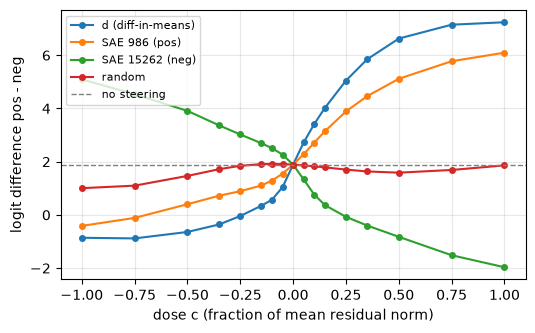

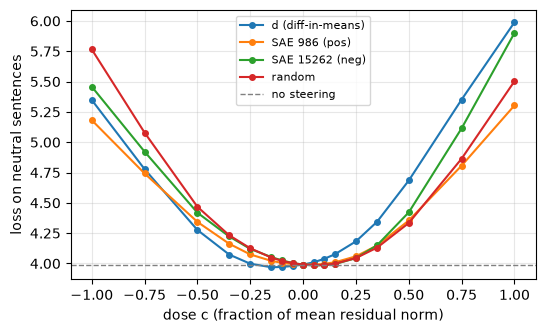

In [4]:
# The comparison: each picked feature's decoder row - what the feature writes into the residual
# stream - through the same sweep as d and a norm-matched random vector. The cosines first: if
# sentiment were a single axis, the two features would be near-antiparallel and both close to d.
# Expectation: every cosine well below 1, the features weaker on the metric per dose than d (d is
# fitted to exactly this contrast), and their loss cost in the same range as d's.
import matplotlib.pyplot as plt

directions = {
    "d (diff-in-means)": d,
    f"SAE {POS_FEATURE} (pos)": W_dec[POS_FEATURE],
    f"SAE {NEG_FEATURE} (neg)": W_dec[NEG_FEATURE],
    "random": r,
}
names = list(directions)
print("cosine between the directions")
print(" " * 20 + "".join(f"{n:>20s}" for n in names))
for a in names:
    print(f"{a:20s}" + "".join(f"{(directions[a] @ directions[b]).item():20.3f}" for b in names))

# how much of d lies in the plane the two features span - the sharpest version of the question
basis = torch.stack([W_dec[POS_FEATURE], W_dec[NEG_FEATURE]]).cpu().T  # lstsq is not on MPS
fit = basis @ torch.linalg.lstsq(basis, d.cpu().unsqueeze(1)).solution
print(f"\nd is unit length; its projection onto the two decoder rows has length {fit.norm():.3f}")

metric_curves = {name: sweep_logit_diff(v) for name, v in directions.items()}
loss_curves = {name: sweep_loss(v) for name, v in directions.items()}

print("\nchange in logit difference / increase in loss, both against the unsteered baseline")
print("    c   " + "".join(f"{n:>20s}" for n in names))
for c in (-1, -0.5, -0.25, -0.1, 0.1, 0.25, 0.5, 1):
    i = coefficients.index(c)
    row = "".join(f"{metric_curves[n][i] - baseline.mean():+11.2f} /{loss_curves[n][i] - baseline_loss:+7.2f}"
                  for n in names)
    print(f"{c:6.2f}   {row}")

def plot_curves(curves, ylabel, baseline_value):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for label, values in curves.items():
        ax.plot(coefficients, values.tolist(), marker="o", ms=4, label=label)
    ax.axhline(baseline_value, color="grey", lw=1, ls="--", label="no steering")
    ax.set_xlabel("dose c (fraction of mean residual norm)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

# Same effect, not same dose: a direction that is weaker per dose can still be the cheaper one.
# Interpolate the dose each direction needs for a +2.00 logit shift and read off the loss there.
import numpy as np

print("\ncost of the same +2.00 logit shift")
for name in names:
    metric = (metric_curves[name] - baseline.mean()).numpy()
    loss = (loss_curves[name] - baseline_loss).numpy()
    order = np.argsort(metric)  # the negative feature reaches the target at negative doses
    if metric.max() < 2.0:
        print(f"  {name:20s} never reaches it")
        continue
    print(f"  {name:20s} at c = {np.interp(2.0, metric[order], np.array(coefficients)[order]):+.3f}, "
          f"loss {np.interp(2.0, metric[order], loss[order]):+.3f}")

plot_curves(metric_curves, "logit difference pos - neg", baseline.mean().item())
plot_curves(loss_curves, "loss on neutral sentences", baseline_loss.item())

## What I take from this

- **Sentiment is not one axis in this SAE.** The positive and negative feature are essentially
  orthogonal (cos 0.049), not two ends of one direction. My `d` correlates with both (0.360 and
  −0.507), and 0.637 of its unit length lies in the plane those two rows span — two of 24 576
  features account for roughly 40 % of `d` in squared terms.
- **Per dose `d` is the stronger lever**, as expected, and it saturates earlier: it is nearly flat
  past c = 0.5 while feature 986 is still climbing at c = 1.
- **At equal effect the advantage disappears.** +2.00 logits costs `d` 0.077 nats at c = 0.139 and
  feature 986 0.069 nats at c = 0.250 — a wash at n = 10 sentences. Feature 15262 needs 0.421 nats
  for the same shift, five times as much. So the SAE direction is not the cleaner intervention
  here; it is a weaker one per dose whose price per unit of effect happens to be similar.
- **Wrong expectations of mine:** I assumed the sparse, "monosemantic" direction would buy the
  same effect at a visibly lower loss. It does not. Right were the weaker per-dose effect, the
  cosines well below 1 and the two features not being antiparallel.
- The random vector never reaches +2.00 at any dose in the range while costing loss like the
  others — the same lesson as station 2: the norm buys the damage, the direction buys the effect.